# Interpretabilità ChessMHA
Cosa sta vedendo il modello?

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import chess
import chess.svg
from IPython.display import display, SVG

from MLChess import ChessMHA, MHA, ChessTransform, generate_all_legal_move_vocab

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = 'chess_mha_checkpoint_without_lambda.pt'

# Nomi delle 7 teste nell'ordine in cui hai stackato M
HEAD_NAMES = ['Pedone bianco', 'Pedone nero', 'Cavallo', 'Alfiere', 'Torre', 'Regina', 'Re']
HEAD_COLORS = ['#f5c518', '#222222', '#7fba00', '#00b4d8', '#e63946', '#9b5de5', '#f77f00']
print('Setup completato.')

Setup completato.


In [2]:
# Carica modello
model = ChessMHA().to(DEVICE)
ckpt = torch.load(CHECKPOINT, map_location=DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()

move_vocab = generate_all_legal_move_vocab()
inv_vocab = {v: k for k, v in move_vocab.items()}
transform = ChessTransform(move_vocab=move_vocab)
print(f'Modello caricato (epoch {ckpt["epoch"]}, val_loss {ckpt["val_loss"]:.4f})')

Modello caricato (epoch 27, val_loss 2.3213)


## 1. Lambda per testa — quanto pesa il prior cinematico?

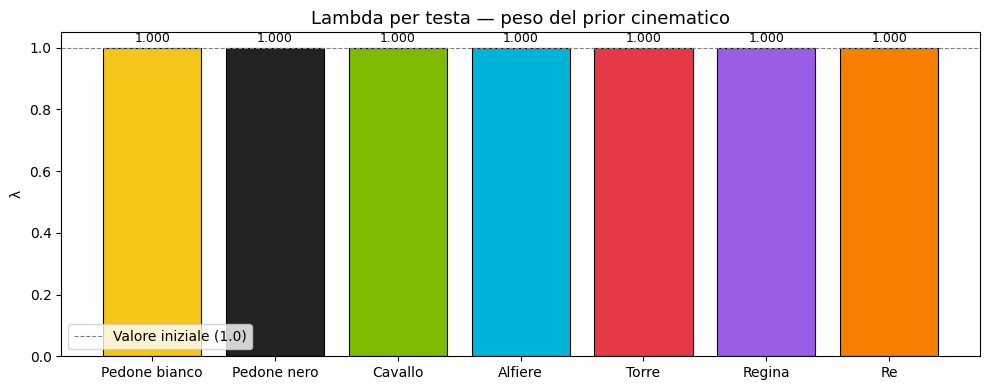


Interpretazione:
  Pedone bianco     : λ=1.000  → Prior cinematico moderato
  Pedone nero       : λ=1.000  → Prior cinematico moderato
  Cavallo           : λ=1.000  → Prior cinematico moderato
  Alfiere           : λ=1.000  → Prior cinematico moderato
  Torre             : λ=1.000  → Prior cinematico moderato
  Regina            : λ=1.000  → Prior cinematico moderato
  Re                : λ=1.000  → Prior cinematico moderato


In [3]:
lambdas = model.mha.lambda_.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(HEAD_NAMES, lambdas, color=HEAD_COLORS, edgecolor='black', linewidth=0.8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Valore iniziale (1.0)')
ax.set_title('Lambda per testa — peso del prior cinematico', fontsize=13)
ax.set_ylabel('λ')
ax.legend()

for bar, val in zip(bars, lambdas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\nInterpretazione:')
for name, lam in zip(HEAD_NAMES, lambdas):
    if lam > 1.2:
        note = '↑ Prior cinematico molto influente'
    elif lam < 0.8:
        note = '↓ Prior cinematico quasi ignorato'
    else:
        note = '→ Prior cinematico moderato'
    print(f'  {name:18s}: λ={lam:.3f}  {note}')

## 2. Mappe di attenzione su una posizione

In [4]:
# Hook per catturare i pesi di attenzione durante il forward
attention_weights = {}

def hook_fn(module, input, output):
    # Ricalcola i pesi di attenzione dall'interno del MHA
    x = input[0]
    batch_size = x.size(0)
    Q = module.q_linear(x).view(batch_size, -1, module.n_heads, module.head_dim).transpose(1, 2)
    K = module.k_linear(x).view(batch_size, -1, module.n_heads, module.head_dim).transpose(1, 2)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (module.head_dim ** 0.5)
    scores = scores + module.lambda_.view(1, 7, 1, 1) * module.matrices_moves
    attention_weights['weights'] = F.softmax(scores, dim=-1).detach().cpu()

hook = model.mha.register_forward_hook(hook_fn)
print('Hook registrato.')

Hook registrato.


In [5]:
def fen_to_tensor(fen):
    board = chess.Board(fen)
    legal_moves = [str(m) for m in board.legal_moves]
    legal_indices = [move_vocab.get(m, -1) for m in legal_moves]
    board_tensor, move_enc, mask, _ = transform(fen, legal_moves[0], legal_indices, '0')
    return board_tensor.unsqueeze(0).to(DEVICE), torch.tensor(mask).unsqueeze(0).to(DEVICE)

def plot_attention_maps(fen, head_idx=None):
    """Plotta le mappe di attenzione per una posizione FEN.
    head_idx=None plotta tutte le teste, altrimenti solo quella indicata.
    """
    board = chess.Board(fen)
    display(SVG(chess.svg.board(board, size=250)))

    board_tensor, mask = fen_to_tensor(fen)
    with torch.no_grad():
        value, policy = model(board_tensor, mask)

    attn = attention_weights['weights'][0]  # (7, 64, 64)

    heads_to_plot = [head_idx] if head_idx is not None else range(7)
    n = len(list(heads_to_plot))
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axes = [axes]

    for ax, h in zip(axes, heads_to_plot):
        # Media dell'attenzione ricevuta da ogni casella (quanto è "guardata")
        attn_map = attn[h].mean(dim=0).numpy().reshape(8, 8)
        # La scacchiera ha rank 0 in basso, ma imshow ha row 0 in alto
        attn_map = np.flipud(attn_map)
        im = ax.imshow(attn_map, cmap='YlOrRd', vmin=0)
        ax.set_title(HEAD_NAMES[h], fontsize=10, color=HEAD_COLORS[h])
        ax.set_xticks(range(8))
        ax.set_yticks(range(8))
        ax.set_xticklabels('abcdefgh')
        ax.set_yticklabels('87654321')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f'Attenzione media per casella\n{fen[:40]}...', fontsize=11)
    plt.tight_layout()
    plt.show()

    val = value.item()
    print(f'\nValutazione modello: {val:.3f} ({"Bianco" if val > 0 else "Nero"} avvantaggiato)')
    return attn

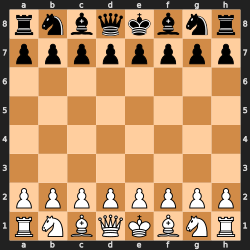

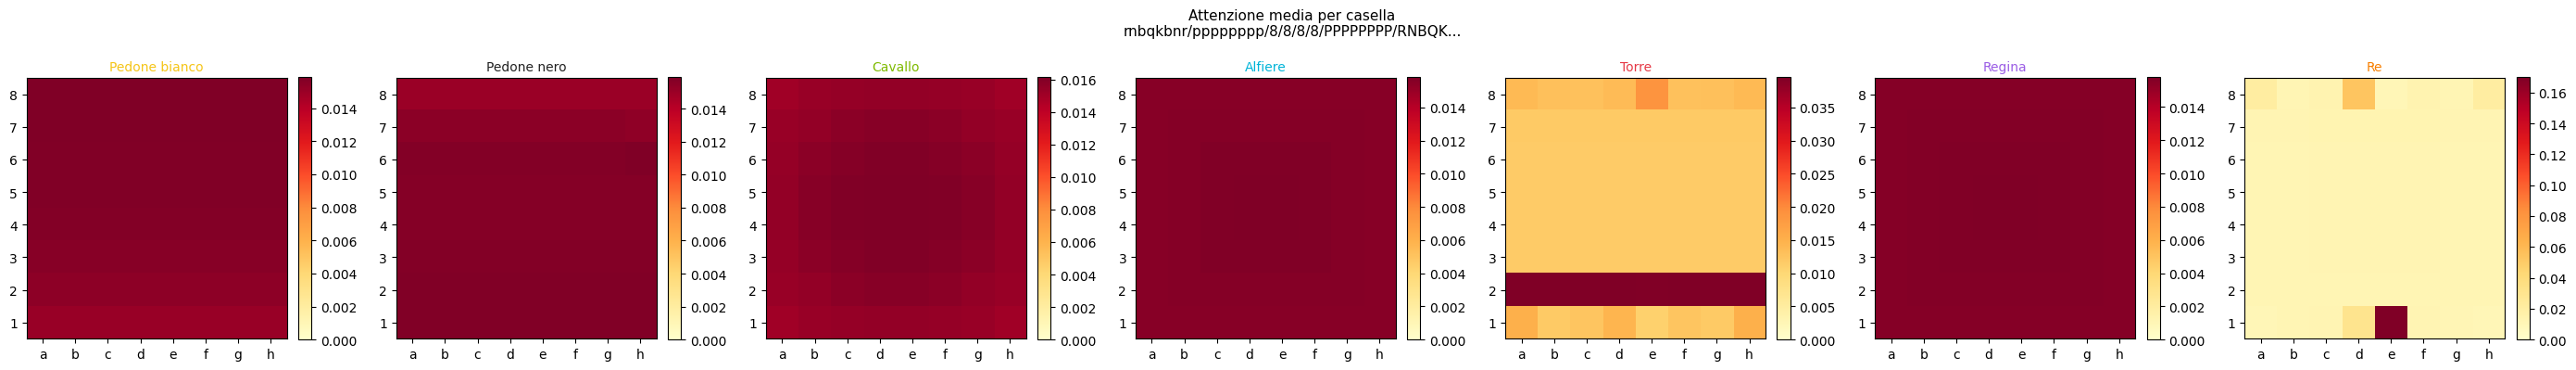


Valutazione modello: 0.101 (Bianco avvantaggiato)


In [6]:
# Posizione iniziale
FEN_START = 'rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1'
attn = plot_attention_maps(FEN_START)

## 3. Forchetta di cavallo — la testa del cavallo vede entrambi i pezzi attaccati?

Forchetta di cavallo: Nc5 attacca re e torre


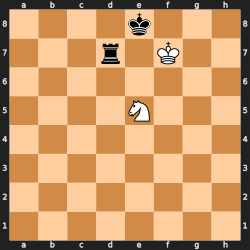

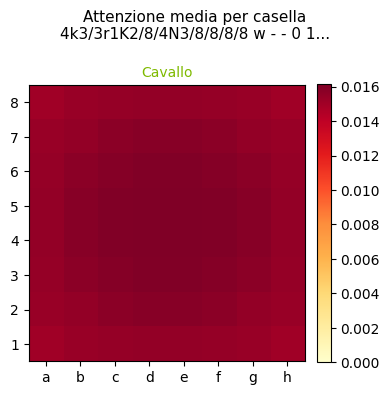


Valutazione modello: 0.124 (Bianco avvantaggiato)


In [7]:
# Cavallo bianco su e5, attacca torre nera su d7 e re nero su f7
FEN_FORK = '4k3/3r1K2/8/4N3/8/8/8/8 w - - 0 1'
print('Forchetta di cavallo: Nc5 attacca re e torre')
attn_fork = plot_attention_maps(FEN_FORK, head_idx=2)  # head 2 = Cavallo

## 4. Policy — top mosse predette su una posizione

Posizione Scholar's mate:


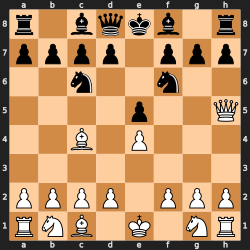

Top 10 mosse predette:
Mossa        Prob     Legale  
--------------------------------
h5e5         0.3641   ✓
c4f7         0.1866   ✓
h5f7         0.1315   ✓
c4b5         0.0848   ✓
h5f5         0.0299   ✓
c4d5         0.0197   ✓
h5h6         0.0178   ✓
h5h7         0.0138   ✓
h5h3         0.0135   ✓
h5h4         0.0127   ✓

Valutazione: 0.259


In [8]:
def show_top_moves(fen, top_k=10):
    board = chess.Board(fen)
    display(SVG(chess.svg.board(board, size=250)))

    board_tensor, mask = fen_to_tensor(fen)
    with torch.no_grad():
        value, policy = model(board_tensor, mask)

    probs = F.softmax(policy[0], dim=-1).cpu().numpy()
    top_indices = probs.argsort()[::-1][:top_k]

    legal = set(str(m) for m in board.legal_moves)

    print(f'Top {top_k} mosse predette:')
    print(f'{"Mossa":12s} {"Prob":8s} {"Legale":8s}')
    print('-' * 32)
    for idx in top_indices:
        move_str = inv_vocab.get(idx, '???')
        prob = probs[idx]
        is_legal = '✓' if move_str in legal else '✗'
        print(f'{move_str:12s} {prob:.4f}   {is_legal}')

    val = value.item()
    print(f'\nValutazione: {val:.3f}')

# Posizione con matto in 1
FEN_MATE1 = 'r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4'
print('Posizione Scholar\'s mate:')
show_top_moves(FEN_MATE1)

## 5. Attenzione partendo da una casella specifica

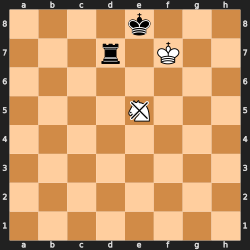

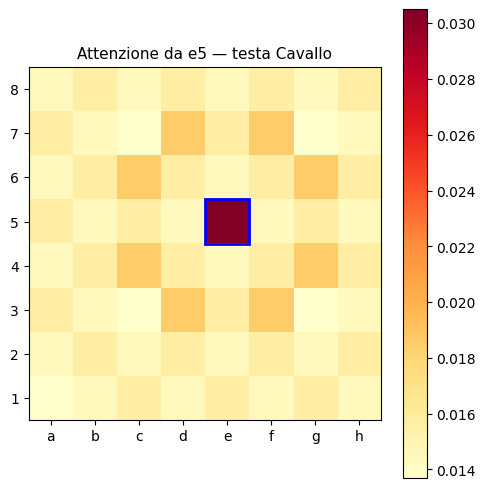

In [9]:
def plot_attention_from_square(fen, square_name, head_idx):
    """Mostra dove guarda la testa `head_idx` partendo dalla casella `square_name`."""
    board = chess.Board(fen)
    sq = chess.parse_square(square_name)
    display(SVG(chess.svg.board(board, squares=chess.SquareSet([sq]), size=250)))

    board_tensor, mask = fen_to_tensor(fen)
    with torch.no_grad():
        model(board_tensor, mask)

    attn = attention_weights['weights'][0]  # (7, 64, 64)
    # File=colonna, Rank=riga — square index = rank*8 + file
    sq_idx = chess.square_rank(sq) * 8 + chess.square_file(sq)
    attn_from_sq = attn[head_idx, sq_idx, :].numpy().reshape(8, 8)
    attn_from_sq = np.flipud(attn_from_sq)

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(attn_from_sq, cmap='YlOrRd')
    ax.set_title(f'Attenzione da {square_name} — testa {HEAD_NAMES[head_idx]}', fontsize=11)
    ax.set_xticks(range(8))
    ax.set_yticks(range(8))
    ax.set_xticklabels('abcdefgh')
    ax.set_yticklabels('87654321')
    # Evidenzia casella sorgente
    file_idx = chess.square_file(sq)
    rank_idx = 7 - chess.square_rank(sq)
    ax.add_patch(plt.Rectangle((file_idx-0.5, rank_idx-0.5), 1, 1,
                                fill=False, edgecolor='blue', linewidth=2))
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

# Esempio: testa cavallo partendo da e5 (posizione forchetta)
plot_attention_from_square(FEN_FORK, 'e5', head_idx=2)

## 6. Confronto M_i vs attenzione appresa

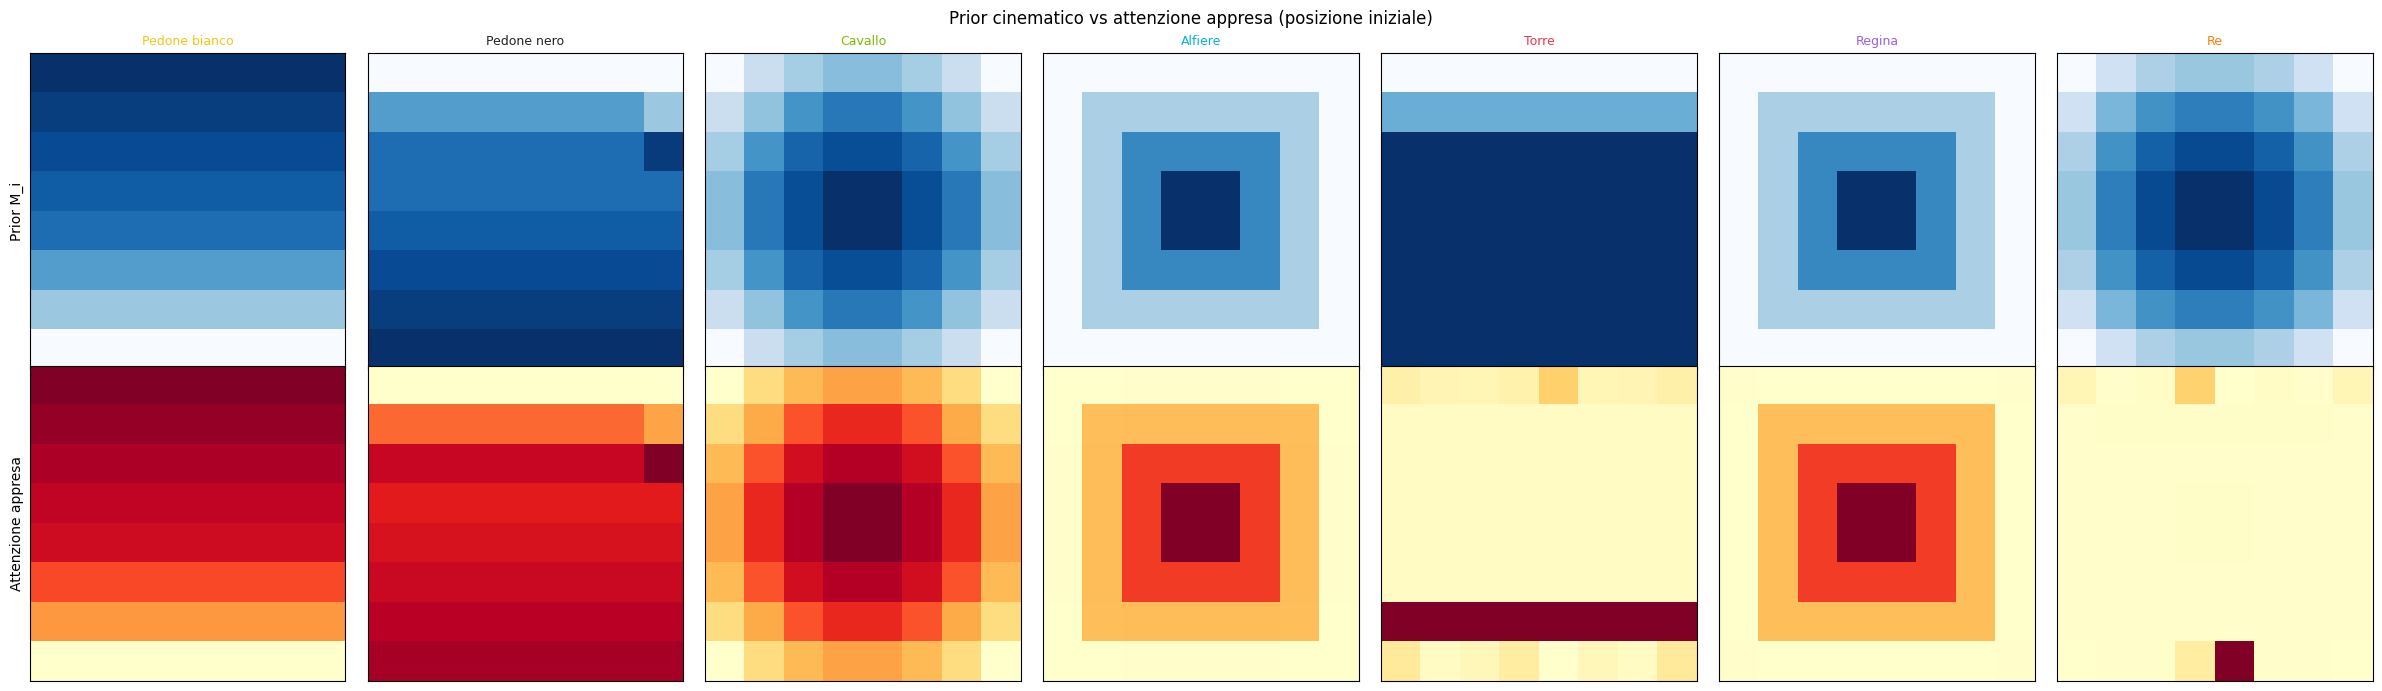

In [10]:
# Visualizza le matrici M_i precompute vs attenzione media sul dataset
M = model.mha.matrices_moves.cpu()  # (7, 64, 64)

fig, axes = plt.subplots(2, 7, figsize=(24, 7))

for h in range(7):
    # Riga 0: M_i (prior cinematico)
    m_map = M[h].mean(dim=0).numpy().reshape(8, 8)
    m_map = np.flipud(m_map)
    axes[0, h].imshow(m_map, cmap='Blues')
    axes[0, h].set_title(HEAD_NAMES[h], fontsize=9, color=HEAD_COLORS[h])
    axes[0, h].set_xticks([])
    axes[0, h].set_yticks([])

    # Riga 1: attenzione appresa (dalla posizione iniziale come esempio)
    a_map = attn[h].mean(dim=0).numpy().reshape(8, 8)
    a_map = np.flipud(a_map)
    axes[1, h].imshow(a_map, cmap='YlOrRd')
    axes[1, h].set_xticks([])
    axes[1, h].set_yticks([])

axes[0, 0].set_ylabel('Prior M_i', fontsize=10)
axes[1, 0].set_ylabel('Attenzione appresa', fontsize=10)

plt.suptitle('Prior cinematico vs attenzione appresa (posizione iniziale)', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Rimuovi hook quando hai finito
hook.remove()
print('Hook rimosso.')

Hook rimosso.
